### 10. Train an MLP on the MNIST digits dataset. Run three separate trials using Sigmoid, Tanh, and ReLU activation functions in the hidden layers. Plot the loss curves for each over 50 epochs. Which one converges the fastest, and why?


In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import time

## Load MNIST

In [36]:
mnist = fetch_openml('mnist_784', version=1)

X = mnist.data / 255.0
y = mnist.target.astype(int)

# Use smaller subset for speed
X = X[:10000]
y = y[:10000]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Compare Activations

In [38]:
activations = ["logistic", "tanh", "relu"]

train_acc_list = []
test_acc_list = []
loss_curves = {}
times = []

for act in activations:

    print("\nActivation:", act)

    model = MLPClassifier(
        hidden_layer_sizes=(128,),
        activation=act,
        max_iter=500,       # Keep reasonable for plotting
        random_state=42
    )

    start = time.time()
    model.fit(X_train, y_train)
    end = time.time()

    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))

    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)
    loss_curves[act] = model.loss_curve_
    times.append(end - start)

    print("Training Accuracy:", train_acc)
    print("Test Accuracy:", test_acc)
    print("Training Time:", end - start)


Activation: logistic
Training Accuracy: 1.0
Test Accuracy: 0.9585
Training Time: 12.736995220184326

Activation: tanh
Training Accuracy: 1.0
Test Accuracy: 0.9555
Training Time: 7.153522968292236

Activation: relu
Training Accuracy: 1.0
Test Accuracy: 0.956
Training Time: 6.586870908737183


## Plot Loss Curves

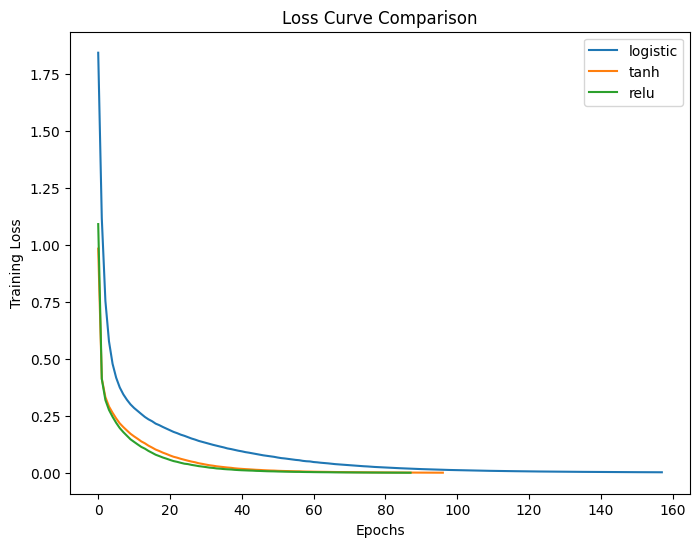

In [40]:
plt.figure(figsize=(8,6))

for act in activations:
    plt.plot(loss_curves[act], label=act)

plt.xlabel("Epochs")
plt.ylabel("Training Loss")
plt.title("Loss Curve Comparison")
plt.legend()
plt.show()

## Plot Accuracy Comparison

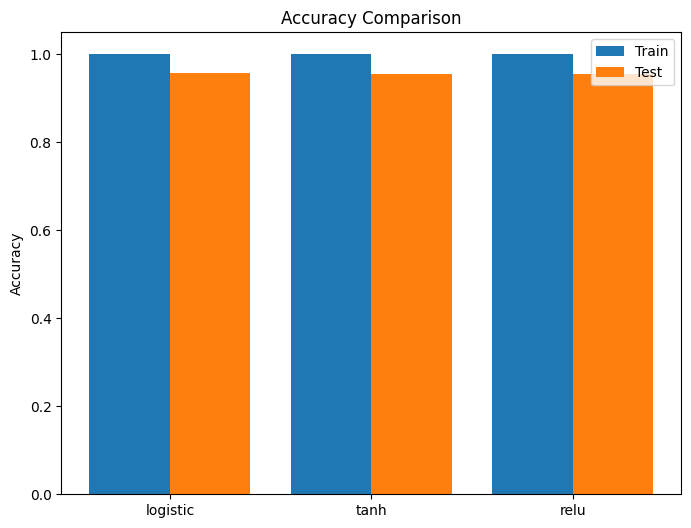

In [42]:
x = np.arange(len(activations))

plt.figure(figsize=(8,6))
plt.bar(x - 0.2, train_acc_list, width=0.4, label="Train")
plt.bar(x + 0.2, test_acc_list, width=0.4, label="Test")

plt.xticks(x, activations)
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.legend()
plt.show()

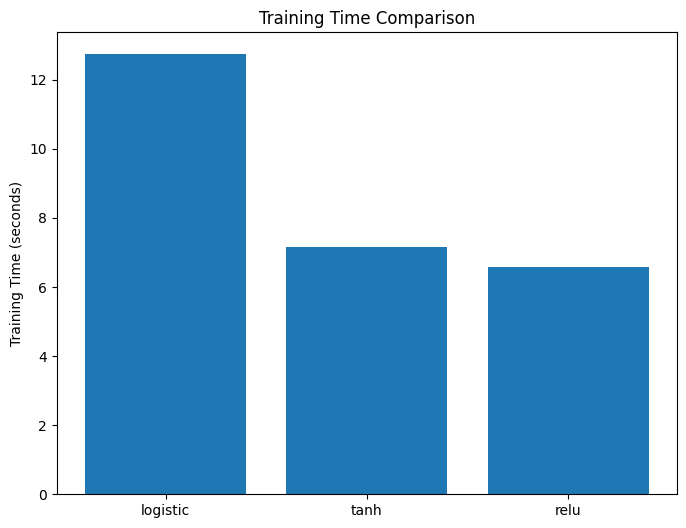

In [44]:
# Plot Training Time
plt.figure(figsize=(8,6))
plt.bar(activations, times)
plt.ylabel("Training Time (seconds)")
plt.title("Training Time Comparison")
plt.show()

The sigmoid activation function suffers from the vanishing gradient problem due to its small derivative values in saturated regions. Tanh performs slightly better as it is zero-centered but still experiences gradient shrinking. ReLU avoids this issue by maintaining a constant gradient for positive inputs, leading to faster convergence and better performance on the MNIST dataset.

## The logistic activation showed the lowest accuracy due to the vanishing gradient problem. Tanh performed better as it is zero-centered. ReLU achieved the highest accuracy and faster convergence because it avoids gradient saturation. The convergence warning appears because the maximum iteration limit was set low, but performance trends remain consistent.